In [2]:

# LIBRARIES

import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from scipy.stats import norm
import nolds  
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:

# DATA PULL
# SPY returns + VIX term structure proxies (2010–present)

START = '2010-01-01'
END   = pd.Timestamp.today().strftime('%Y-%m-%d')

# --- Download ---
raw = yf.download(
    tickers=['SPY', '^VIX', '^VIX3M', '^VIX6M'],
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)['Close']

raw.columns = ['SPY', 'VIX', 'VIX3M', 'VIX6M']

# --- SPY log returns ---
raw['SPY_ret'] = np.log(raw['SPY'] / raw['SPY'].shift(1))

# --- Drop weekends/holidays (yfinance occasionally leaks these) ---
df = raw.dropna(subset=['SPY', 'VIX', 'VIX3M', 'VIX6M']).copy()

# --- Sanity checks ---
print(f"Date range  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Observations: {len(df):,}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nVIX  range: {df['VIX'].min():.1f} → {df['VIX'].max():.1f}")
print(f"VIX3M range: {df['VIX3M'].min():.1f} → {df['VIX3M'].max():.1f}")
print(f"VIX6M range: {df['VIX6M'].min():.1f} → {df['VIX6M'].max():.1f}")

Date range  : 2010-01-04 → 2026-04-24
Observations: 4,102
Missing values:
SPY        0
VIX        0
VIX3M      0
VIX6M      0
SPY_ret    1
dtype: int64

VIX  range: 9.1 → 82.7
VIX3M range: 11.9 → 73.0
VIX6M range: 13.8 → 61.1


In [4]:

# VIX TERM STRUCTURE → VARIANCE SPACE
# --- Convert vol → variance ---
df['VAR_30']  = (df['VIX']  / 100) ** 2   # 30d Q-implied variance
df['VAR_93']  = (df['VIX3M']/ 100) ** 2   # 93d Q-implied variance
df['VAR_180'] = (df['VIX6M']/ 100) ** 2   # 180d Q-implied variance

# --- Term structure slope (raw, in variance space) ---
df['SLOPE_30_93']  = df['VAR_93']  - df['VAR_30']
df['SLOPE_93_180'] = df['VAR_180'] - df['VAR_93']
df['SLOPE_30_180'] = df['VAR_180'] - df['VAR_30']  # full curve slope

# --- Regime labels (based on VIX spot level) ---
df['REGIME'] = pd.cut(
    df['VIX'],
    bins=[0, 15, 25, np.inf],
    labels=['Low (<15)', 'Medium (15–25)', 'High (>25)']
)

# --- Summary ---
print("=== Variance Term Structure Summary ===\n")
print(df[['VAR_30','VAR_93','VAR_180']].describe().round(5))
print("\n=== Slope Summary (VAR_93 − VAR_30) ===")
print(df['SLOPE_30_93'].describe().round(5))
print(f"\nSlope < 0 (inverted) : {(df['SLOPE_30_93'] < 0).sum():,} days "
      f"({(df['SLOPE_30_93'] < 0).mean()*100:.1f}% of sample)")

print("\n=== Regime Distribution ===")
print(df['REGIME'].value_counts().sort_index())

=== Variance Term Structure Summary ===

         VAR_30    VAR_93   VAR_180
count 4102.0000 4102.0000 4102.0000
mean     0.0387    0.0452    0.0507
std      0.0385    0.0327    0.0282
min      0.0083    0.0140    0.0189
25%      0.0190    0.0253    0.0308
50%      0.0280    0.0363    0.0426
75%      0.0447    0.0523    0.0606
max      0.6838    0.5326    0.3734

=== Slope Summary (VAR_93 − VAR_30) ===
count   4102.0000
mean       0.0064
std        0.0114
min       -0.2419
25%        0.0043
50%        0.0067
75%        0.0101
max        0.0361
Name: SLOPE_30_93, dtype: float64

Slope < 0 (inverted) : 321 days (7.8% of sample)

=== Regime Distribution ===
REGIME
Low (<15)         1441
Medium (15–25)    2106
High (>25)         555
Name: count, dtype: int64


In [5]:

# GARCH(1,1) MODEL
# Fit on SPY log returns to get conditional variance forecasts

# --- Scale returns (arch library works in % returns) ---
ret = df['SPY_ret'].dropna() * 100

# --- Specify and fit GARCH(1,1) ---
garch = arch_model(
    ret,
    vol='Garch',
    p=1, q=1,
    mean='Constant',
    dist='normal'
)

res = garch.fit(disp='off')

# --- Print parameter summary ---
print(res.summary())

# --- Store conditional variance back in df (in decimal, annualised) ---
df.loc[ret.index, 'GARCH_VAR_daily'] = res.conditional_volatility ** 2 / 10000
df['GARCH_VAR_ann'] = df['GARCH_VAR_daily'] * 252

# --- Key parameters ---
omega = res.params['omega']
alpha = res.params['alpha[1]']
beta  = res.params['beta[1]']
phi   = alpha + beta  # persistence

print(f"\n=== GARCH Parameters ===")
print(f"omega  (ω) : {omega:.6f}")
print(f"alpha  (α) : {alpha:.4f}")
print(f"beta   (β) : {beta:.4f}")
print(f"phi    (φ = α+β) : {phi:.4f}")
print(f"Long-run daily variance (ω/1-φ) : {omega/(1-phi):.6f}")
print(f"Long-run ann. vol : {np.sqrt(omega/(1-phi) * 252 * 10000):.2f}%")
print(f"Long-run ann. vol : {np.sqrt(omega/(1-phi) / 10000 * 252)*100:.2f}%")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                SPY_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5268.43
Distribution:                  Normal   AIC:                           10544.9
Method:            Maximum Likelihood   BIC:                           10570.1
                                        No. Observations:                 4101
Date:                Sun, Apr 26 2026   Df Residuals:                     4100
Time:                        10:40:06   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0852  1.176e-02      7.249  4.186e-13 [6.218e-0

In [6]:
phi = 0.9668
print(f"phi^30  = {phi**30:.4f}")
print(f"phi^90  = {phi**90:.4f}")

phi^30  = 0.3632
phi^90  = 0.0479


In [6]:

# MULTI-STEP GARCH FORECASTS
# Construct P-measure integrated variance at 30, 93, 180d


# --- Unconditional variance (in %-squared space) ---
sigma2_bar = omega / (1 - phi)

# --- Daily conditional variance from fitted model (%-squared space) ---
h_t = res.conditional_volatility ** 2  # shape: (4101,)

# --- Closed-form multi-step integrated variance ---
# E[IV(τ)] = τ·σ̄² + (h_t - σ̄²) · φ(1 - φᵗ)/(1 - φ)
# This is the sum of h_{t+1} + h_{t+2} + ... + h_{t+τ}

def garch_integrated_variance(h_t, sigma2_bar, phi, tau):
    """
    Returns GARCH integrated variance over tau steps.
    All quantities in %-squared space.
    Output converted to annualised decimal variance.
    """
    shock = h_t - sigma2_bar
    # Geometric sum of decaying shock contributions
    decay_sum = phi * (1 - phi**tau) / (1 - phi)
    iv = tau * sigma2_bar + shock * decay_sum
    # Convert: %-squared → decimal → annualise
    return (iv / tau) * (1/10000) * 252

# --- Compute for each horizon ---
iv_30  = garch_integrated_variance(h_t, sigma2_bar, phi, 30)
iv_93  = garch_integrated_variance(h_t, sigma2_bar, phi, 93)
iv_180 = garch_integrated_variance(h_t, sigma2_bar, phi, 180)

# --- Store in df ---
df.loc[ret.index, 'GARCH_IV_30']  = iv_30
df.loc[ret.index, 'GARCH_IV_93']  = iv_93
df.loc[ret.index, 'GARCH_IV_180'] = iv_180

# --- Sanity check: long-run GARCH vol at each horizon ---
print("=== GARCH Integrated Variance — Summary ===\n")
print(df[['GARCH_IV_30','GARCH_IV_93','GARCH_IV_180']].describe().round(5))

print(f"\n=== Convergence Check ===")
print(f"Long-run ann. variance (σ̄²×252) : {sigma2_bar/10000*252:.5f}")
print(f"Mean GARCH_IV_30  : {df['GARCH_IV_30'].mean():.5f}")
print(f"Mean GARCH_IV_93  : {df['GARCH_IV_93'].mean():.5f}")
print(f"Mean GARCH_IV_180 : {df['GARCH_IV_180'].mean():.5f}")

=== GARCH Integrated Variance — Summary ===

       GARCH_IV_30  GARCH_IV_93  GARCH_IV_180
count    4101.0000    4101.0000     4101.0000
mean        0.0294       0.0293        0.0292
std         0.0363       0.0176        0.0095
min         0.0144       0.0220        0.0253
25%         0.0178       0.0236        0.0262
50%         0.0214       0.0254        0.0271
75%         0.0297       0.0294        0.0293
max         0.8136       0.4093        0.2340

=== Convergence Check ===
Long-run ann. variance (σ̄²×252) : 0.02915
Mean GARCH_IV_30  : 0.02938
Mean GARCH_IV_93  : 0.02926
Mean GARCH_IV_180 : 0.02921


In [7]:

# VRP TERM STRUCTURE CONSTRUCTION
# VRP(τ) = Q-implied variance − P-measure GARCH forecast


# --- Core VRP at each horizon ---
df['VRP_30']  = df['VAR_30']  - df['GARCH_IV_30']
df['VRP_93']  = df['VAR_93']  - df['GARCH_IV_93']
df['VRP_180'] = df['VAR_180'] - df['GARCH_IV_180']

# --- Term structure slope of VRP ---
df['VRP_SLOPE_30_93']  = df['VRP_93']  - df['VRP_30']
df['VRP_SLOPE_93_180'] = df['VRP_180'] - df['VRP_93']
df['VRP_SLOPE_30_180'] = df['VRP_180'] - df['VRP_30']  # full curve

# --- Normalised VRP (Bollerslev et al.) ---
# Divides by VIX² to control for vol level effects
df['NVRP_30']  = df['VRP_30']  / df['VAR_30']
df['NVRP_93']  = df['VRP_93']  / df['VAR_93']
df['NVRP_180'] = df['VRP_180'] / df['VAR_180']

# --- Summary ---
print("=== VRP Term Structure Summary ===\n")
print(df[['VRP_30','VRP_93','VRP_180']].describe().round(5))

print("\n=== VRP Slope Summary ===")
print(df[['VRP_SLOPE_30_93','VRP_SLOPE_30_180']].describe().round(5))

print("\n=== VRP Sign (% positive = market charges premium) ===")
for col in ['VRP_30','VRP_93','VRP_180']:
    pct = (df[col] > 0).mean() * 100
    print(f"{col}: {pct:.1f}% positive")

print("\n=== VRP by Regime ===")
print(df.groupby('REGIME', observed=True)[['VRP_30','VRP_93','VRP_180']].mean().round(5))

=== VRP Term Structure Summary ===

         VRP_30    VRP_93   VRP_180
count 4101.0000 4101.0000 4101.0000
mean     0.0093    0.0159    0.0215
std      0.0209    0.0221    0.0233
min     -0.2374   -0.0640   -0.0123
25%     -0.0012    0.0005    0.0040
50%      0.0048    0.0092    0.0144
75%      0.0151    0.0232    0.0314
max      0.2692    0.1671    0.1627

=== VRP Slope Summary ===
       VRP_SLOPE_30_93  VRP_SLOPE_30_180
count        4101.0000         4101.0000
mean            0.0066            0.0122
std             0.0144            0.0175
min            -0.1022           -0.1406
25%             0.0001            0.0030
50%             0.0037            0.0086
75%             0.0093            0.0175
max             0.3065            0.3038

=== VRP Sign (% positive = market charges premium) ===
VRP_30: 68.3% positive
VRP_93: 76.9% positive
VRP_180: 90.1% positive

=== VRP by Regime ===
                VRP_30  VRP_93  VRP_180
REGIME                                 
Low (<15)      

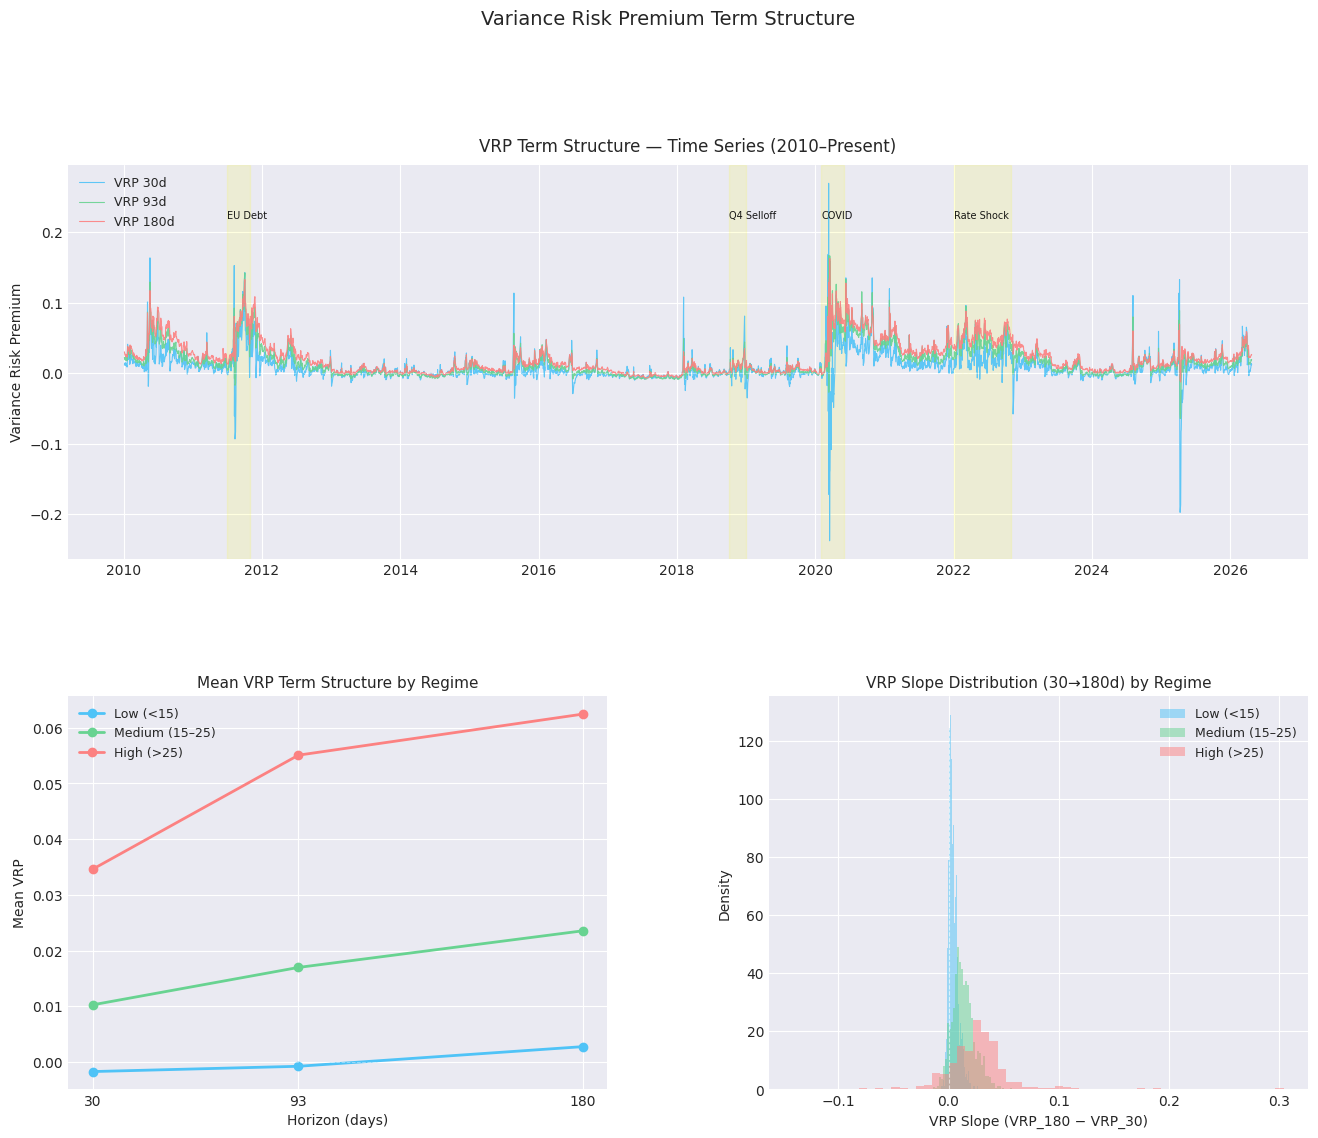

Figure saved.


In [ ]:

# VISUALISATION

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# --- Colour scheme ---
c30  = '#4fc3f7'
c93  = '#68d391'
c180 = '#fc8181'
regime_colors = {
    'Low (<15)'      : '#4fc3f7',
    'Medium (15–25)' : '#68d391',
    'High (>25)'     : '#fc8181'
}


# Figure 1 — VRP time series at all three horizons
ax1 = fig.add_subplot(gs[0, :])

ax1.plot(df.index, df['VRP_30'],  color=c30,  lw=0.8, alpha=0.9, label='VRP 30d')
ax1.plot(df.index, df['VRP_93'],  color=c93,  lw=0.8, alpha=0.9, label='VRP 93d')
ax1.plot(df.index, df['VRP_180'], color=c180, lw=0.8, alpha=0.9, label='VRP 180d')
ax1.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.4)

crises = [('2011-07-01', '2011-10-31', 'EU Debt'),
          ('2018-10-01', '2018-12-31', 'Q4 Selloff'),
          ('2020-02-01', '2020-05-31', 'COVID'),
          ('2022-01-01', '2022-10-31', 'Rate Shock')]

for start, end, label in crises:
    ax1.axvspan(start, end, alpha=0.12, color='yellow')
    ax1.text(pd.Timestamp(start), 0.22,
             label, fontsize=7, color='black', alpha=0.9)
    
ax1.set_title('VRP Term Structure — Time Series (2010–Present)', fontsize=12, pad=10)
ax1.set_ylabel('Variance Risk Premium')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))

# Figure 2 — Average VRP term structure by regime
ax2 = fig.add_subplot(gs[1, 0])

horizons = [30, 93, 180]
for regime, color in regime_colors.items():
    subset = df[df['REGIME'] == regime]
    means  = [subset['VRP_30'].mean(),
              subset['VRP_93'].mean(),
              subset['VRP_180'].mean()]
    ax2.plot(horizons, means, 'o-', color=color, lw=2,
             markersize=6, label=regime)

ax2.axhline(0, color='white', lw=0.7, linestyle='--', alpha=0.4)
ax2.set_title('Mean VRP Term Structure by Regime', fontsize=11)
ax2.set_xlabel('Horizon (days)')
ax2.set_ylabel('Mean VRP')
ax2.set_xticks(horizons)
ax2.legend(fontsize=9)


# Figure 3 — VRP slope distribution by regime
ax3 = fig.add_subplot(gs[1, 1])

for regime, color in regime_colors.items():
    subset = df[df['REGIME'] == regime]['VRP_SLOPE_30_180'].dropna()
    ax3.hist(subset, bins=60, alpha=0.5, color=color,
             label=regime, density=True)

ax3.axvline(0, color='white', lw=0.8, linestyle='--', alpha=0.6)
ax3.set_title('VRP Slope Distribution (30→180d) by Regime', fontsize=11)
ax3.set_xlabel('VRP Slope (VRP_180 − VRP_30)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

plt.suptitle('Variance Risk Premium Term Structure', fontsize=14, y=1.01)
plt.savefig('vrp_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [ ]:

# REGIME ANALYSIS TABLE
# Clean summary of VRP term structure by regime

# --- Mean VRP by regime ---
regime_summary = df.groupby('REGIME', observed=True).agg(
    Days        = ('VRP_30', 'count'),
    VRP_30_mean = ('VRP_30', 'mean'),
    VRP_93_mean = ('VRP_93', 'mean'),
    VRP_180_mean= ('VRP_180','mean'),
    Slope_mean  = ('VRP_SLOPE_30_180', 'mean'),
    Slope_std   = ('VRP_SLOPE_30_180', 'std'),
    Inversion_pct = ('VRP_SLOPE_30_180', lambda x: (x < 0).mean() * 100)
).round(5)

print("=== VRP Term Structure by Regime ===\n")
print(regime_summary.to_string())

# --- Full sample statistics ---
print("\n=== Full Sample VRP Summary ===")
full = pd.DataFrame({
    'Horizon'    : ['30d', '93d', '180d'],
    'Mean VRP'   : [df['VRP_30'].mean(), df['VRP_93'].mean(), df['VRP_180'].mean()],
    'Std VRP'    : [df['VRP_30'].std(),  df['VRP_93'].std(),  df['VRP_180'].std()],
    'Pct Positive': [(df['VRP_30']>0).mean()*100,
                     (df['VRP_93']>0).mean()*100,
                     (df['VRP_180']>0).mean()*100],
    'Sharpe VRP' : [df['VRP_30'].mean()/df['VRP_30'].std(),
                    df['VRP_93'].mean()/df['VRP_93'].std(),
                    df['VRP_180'].mean()/df['VRP_180'].std()]
}).round(4)

print(full.to_string(index=False))

# --- Slope steepening in stress ---
print("\n=== Slope Steepening: High vs Low Regime ===")
high = df[df['REGIME']=='High (>25)']['VRP_SLOPE_30_180'].mean()
low  = df[df['REGIME']=='Low (<15)']['VRP_SLOPE_30_180'].mean()
print(f"Mean slope in High regime : {high:.5f}")
print(f"Mean slope in Low regime  : {low:.5f}")
print(f"Steepening ratio          : {high/low:.2f}x")

=== VRP Term Structure by Regime ===

                Days  VRP_30_mean  VRP_93_mean  VRP_180_mean  Slope_mean  Slope_std  Inversion_pct
REGIME                                                                                            
Low (<15)       1441      -0.0017      -0.0008        0.0027      0.0045     0.0044        10.6870
Medium (15–25)  2105       0.0103       0.0170        0.0236      0.0133     0.0103         7.9772
High (>25)       555       0.0346       0.0551        0.0624      0.0278     0.0374        12.6126

=== Full Sample VRP Summary ===
Horizon  Mean VRP  Std VRP  Pct Positive  Sharpe VRP
    30d    0.0093   0.0210       68.3325      0.4458
    93d    0.0159   0.0221       76.8649      0.7198
   180d    0.0215   0.0233       90.1024      0.9232

=== Slope Steepening: High vs Low Regime ===
Mean slope in High regime : 0.02785
Mean slope in Low regime  : 0.00447
Steepening ratio          : 6.23x
